In [10]:
#Feature Importance
#Random Forest
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

rf_importance.sort_values(
    by="Importance",
    ascending=False
)

#XGBoost
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,rating,0.154944
5,shipment_value,0.154647
2,lead_time,0.145398
6,supplier_avg_delay,0.144717
1,unit_price,0.141688
0,shipment_quantity,0.129729
3,stock_quantity,0.128878


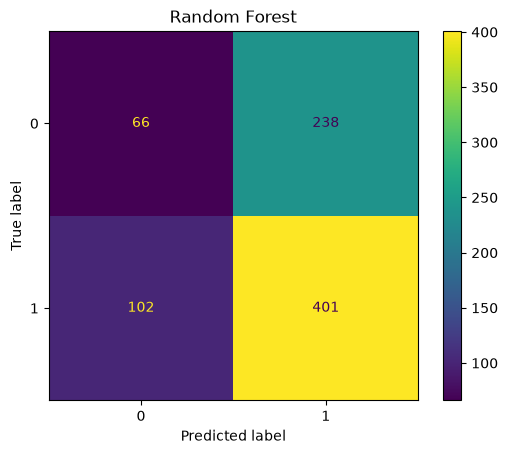

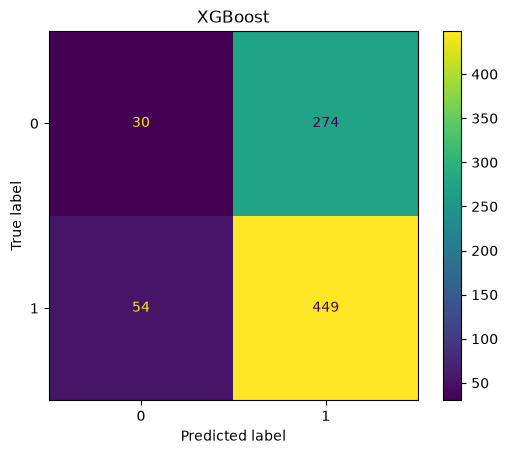

In [9]:
#Confusion Matrix
#Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest")

plt.show()

#XGBoost
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred
)

plt.title("XGBoost")

plt.show()

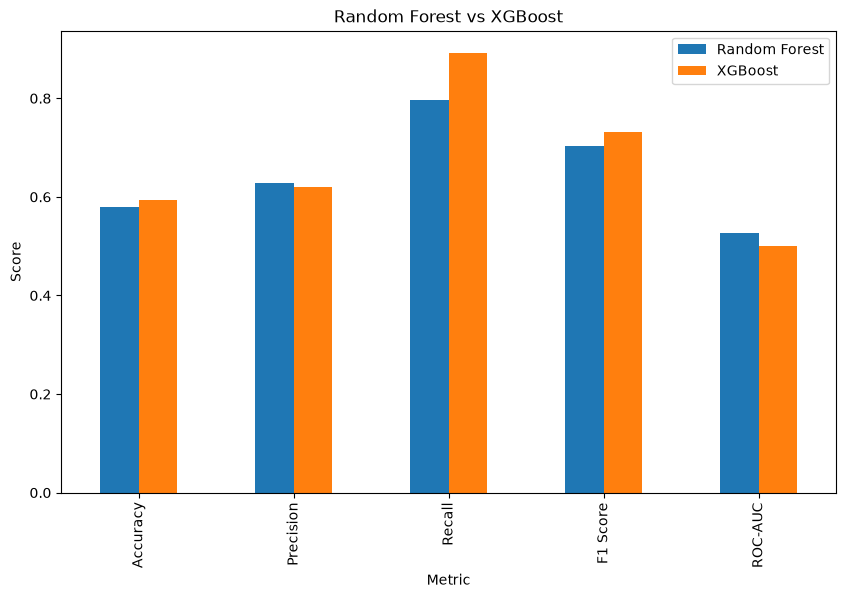

In [8]:
#Plot Result
results.set_index("Metric").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Random Forest vs XGBoost")

plt.ylabel("Score")

plt.show()

In [ ]:
#Compare Result
print(results)

In [7]:
#Evaluate Both Model
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Random Forest": [

        accuracy_score(y_test, rf_pred),

        precision_score(y_test, rf_pred),

        recall_score(y_test, rf_pred),

        f1_score(y_test, rf_pred),

        roc_auc_score(
            y_test,
            rf.predict_proba(X_test)[:,1]
        )
    ],

    "XGBoost": [

        accuracy_score(y_test, xgb_pred),

        precision_score(y_test, xgb_pred),

        recall_score(y_test, xgb_pred),

        f1_score(y_test, xgb_pred),

        roc_auc_score(
            y_test,
            xgb.predict_proba(X_test)[:,1]
        )
    ]
})

results

,Metric,Random Forest,XGBoost
0,Accuracy,0.578686,0.593556
1,Precision,0.627543,0.621024
2,Recall,0.797217,0.892644
3,F1 Score,0.702277,0.732463
4,ROC-AUC,0.527045,0.500690


In [6]:
#Train XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [5]:
#Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [4]:
#Train-Test spilt
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [3]:
#Select Features
features = [
    "shipment_quantity",
    "unit_price",
    "lead_time",
    "stock_quantity",
    "rating",
    "shipment_value",
    "supplier_avg_delay"
]

X = df[features]
y = df["is_delayed"]

In [2]:
#Load Dataset
df = pd.read_csv("../data/feature_engineered_supply_chain.csv")

In [1]:
# Day 6 - Model Evaluation
## Comparing Random Forest vs XGBoost
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)